## **Importação das bibliotecas e datasets e criação das funções**

In [1]:
import json
import os
import sys
import io
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from keras.layers import Dense,Dropout,SimpleRNN,LSTM #Biblioteca para deep learning
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

# Configurar a seed para o Python, NumPy e TensorFlow
SEED = 42  # valor fixo que será utilizado como seed

# Seed para o Python
random.seed(SEED)

# Seed para o NumPy (usado para operações de matriz e aleatoriedade fora do TensorFlow)
np.random.seed(SEED)

# Seed para o TensorFlow
tf.random.set_seed(SEED)

In [2]:
base_path = './dataset/'
time_base = 'days'
agrupamento = "3"
datasets = "concat"
dataset_type_du = f"{agrupamento}_days_{datasets}"
tt_rate_new = 0.8

In [3]:
# Carregar o arquivo JSON
with open('config_pso.json') as f:
    config = json.load(f)

In [4]:
# Cria um diretório específico se não existir
diretorio_pesos_teste_1 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/pesos/teste_1__{tt_rate_new}"
os.makedirs(diretorio_pesos_teste_1, exist_ok=True)

diretorio_pesos_teste_3 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/pesos/teste_3__{tt_rate_new}"
os.makedirs(diretorio_pesos_teste_3, exist_ok=True)

diretorio_avaliacao_teste_0 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/avaliacao_testes/teste_0"
os.makedirs(diretorio_avaliacao_teste_0, exist_ok=True)

diretorio_avaliacao_teste_1 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/avaliacao_testes/teste_1__{tt_rate_new}"
os.makedirs(diretorio_avaliacao_teste_1, exist_ok=True)

diretorio_avaliacao_teste_2 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/avaliacao_testes/teste_2"
os.makedirs(diretorio_avaliacao_teste_2, exist_ok=True)

diretorio_avaliacao_teste_3 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/avaliacao_testes/teste_3__{tt_rate_new}"
os.makedirs(diretorio_avaliacao_teste_3, exist_ok=True)

diretorio_avaliacao_teste_4 = f"Resultados_PSO/pso_{datasets}/{agrupamento}_days/avaliacao_testes/teste_4"
os.makedirs(diretorio_avaliacao_teste_4, exist_ok=True)


In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))  # Padronização dos dados

duas_unas_dataset = f'C:/Users/Renan Torres/OneDrive/Documentos/Github/dataset/duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
prataI_dataset = f'C:/Users/Renan Torres/OneDrive/Documentos/Github/dataset/outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
prataII_dataset = f'C:/Users/Renan Torres/OneDrive/Documentos/Github/dataset/outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
prataIII_dataset = f'C:/Users/Renan Torres/OneDrive/Documentos/Github/dataset/outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
pirapama_dataset = f'C:/Users/Renan Torres/OneDrive/Documentos/Github/dataset/outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

# duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_{agrupamento}_{time_base}.csv'
# prataI_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_I_{agrupamento}_{time_base}.csv'
# prataII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_II_{agrupamento}_{time_base}.csv'
# prataIII_dataset = f'{base_path}outras_unidades/{time_base}/PRATA_III_{agrupamento}_{time_base}.csv'
# pirapama_dataset = f'{base_path}outras_unidades/pirapama/Pirapama_{agrupamento}_{time_base}.csv'

In [6]:
# transformando CSV em DataFrame
duas_unas_df = pd.read_csv(duas_unas_dataset)  # Transformação em dataset
prataI_df = pd.read_csv(prataI_dataset)  # Transformação em dataset
prataII_df = pd.read_csv(prataII_dataset)  # Transformação em dataset
prataIII_df = pd.read_csv(prataIII_dataset)  # Transformação em dataset
pirapama_df = pd.read_csv(pirapama_dataset)  # Transformação em dataset

In [7]:
validation_interval = config['datasets'][dataset_type_du]['timesteps'] + config['datasets'][dataset_type_du]['output_horizon'] # Definição da parcela dos dados que serão retiradas do treinamento/teste para validação
horizonte = config['datasets'][dataset_type_du]['output_horizon']
#print(f'validation interval',validation_interval)

indices_to_validate = duas_unas_df.index[-validation_interval:].tolist()  # Obtenção dos índices dos dadoss de validação

datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]  # df1, df2, etc., são os seus dataframes

# Aplicar MinMaxScaler para cada dataset individualmente
scaled_datasets = []
scalers = []
for i, df in enumerate(datasets):
    # Garantir que 'timestamp' é do tipo datetime e já está configurado corretamente como índice
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values(by='timestamp')
        df.set_index('timestamp', inplace=True)

    # Aplicar o scaler apenas nas colunas numéricas
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[float, int]))  # Apenas colunas numéricas
    scaled_df = pd.DataFrame(scaled_data, columns=df.select_dtypes(include=[float, int]).columns, index=df.index)
    
    # Adicionar o DataFrame escalado à lista
    scaled_datasets.append(scaled_df)
    scalers.append(scaler)  # Salvar o scaler específico para este dataset

# print(scaled_datasets[4].index)
# print(indices_to_validate)

# duas_unas_df_scaled = scaled_datasets[4].iloc[~scaled_datasets[4].index.isin(indices_to_validate)].reset_index(drop=True)
# print(duas_unas_df_scaled)
duas_unas_validation_scaled = scaled_datasets[4].tail(validation_interval)  # Criação do dataset de validação
#print(duas_unas_validation_scaled)
#duas_unas_df_scaled = scaled_datasets[4].drop(tail(indices_to_validate.shape)).reset_index(drop=True)  # Retirada dos dados de validação do dataset original de treino/teste

# Define o número de linhas a serem removidas
X = len(indices_to_validate)
duas_unas_df_scaled = scaled_datasets[4].iloc[:-X]
#print(duas_unas_df_scaled)
# print(duas_unas_validation_scaled)

scaled_datasets[4] = duas_unas_df_scaled

In [8]:
def save_function_output(func, *args, output_file, output_dir, **kwargs):
    # Redireciona stdout para capturar os prints
    old_stdout = sys.stdout
    new_stdout = io.StringIO()
    sys.stdout = new_stdout
    
    try:
        # Executa a função e captura sua saída
        func(*args, **kwargs)
    finally:
        # Restaura stdout e captura a saída
        sys.stdout = old_stdout
        output = new_stdout.getvalue()
        
        # Cria o diretório se não existir
        os.makedirs(output_dir, exist_ok=True)
        
        # Caminho completo para o arquivo de saída
        save_path = os.path.join(output_dir, output_file)
        
        # Salva a saída em um arquivo
        with open(save_path, 'w') as f:
            f.write(output)
        print(f"Output salvo em: {save_path}")

In [9]:
def identify_peaks_and_valleys(y_test):
    # Converte y_test em um tensor
    #y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    # Inicializa pesos como um tensor de 1s do mesmo formato
    weights = tf.ones(tf.shape(y_test), dtype=tf.float32)

    # Condicional para verificar se y_test tem pelo menos 3 elementos
    mask = tf.size(y_test) < 3

    # Função para processar picos e vales
    def process_peaks_and_valleys():
        # Certifique-se de que y_test é do tipo float32
        y_test_float = tf.cast(y_test, tf.float32)

        # Obtém os índices de picos e vales para elementos intermediários
        # Corrigido: use tf.expand_dims para garantir que o primeiro elemento tenha o formato correto
        y_test_prev = tf.concat([tf.expand_dims(y_test_float[0], axis=0), y_test_float[:-1]], axis=0)  # Adiciona o primeiro elemento como anterior
        y_test_next = tf.concat([y_test_float[1:], tf.expand_dims(y_test_float[-1], axis=0)], axis=0)  # Adiciona o último elemento como próximo

        # Define picos e vales para os elementos intermediários
        peaks = tf.where((y_test_float > y_test_prev) & (y_test_float > y_test_next))
        valleys = tf.where((y_test_float < y_test_prev) & (y_test_float < y_test_next))

        # Atualiza os pesos para picos e vales intermediários
        weights_updated = tf.tensor_scatter_nd_update(weights, peaks, tf.fill(tf.shape(peaks)[:1], 3.0))
        weights_updated = tf.tensor_scatter_nd_update(weights_updated, valleys, tf.fill(tf.shape(valleys)[:1], 3.0))

        return weights_updated

    # Condicional para executar a função de processamento se y_test tiver 3 ou mais elementos
    weights = tf.cond(mask, lambda: weights, process_peaks_and_valleys)

    return weights


In [10]:
# Função WMAE ajustada com pesos para picos e vales
def wmae(y_test, y_pred):
    # Convertendo y_test e y_pred para float32
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    #y_test = tf.squeeze(y_test)
    #y_pred = tf.squeeze(y_pred)

    weights = identify_peaks_and_valleys(y_test)

    return (tf.reduce_sum(weights * tf.abs(y_test - y_pred)) / tf.reduce_sum(weights))

In [11]:
def wmse(y_test, y_pred):
    y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)
    y_pred = tf.convert_to_tensor(y_pred, dtype=tf.float32)

    weights = identify_peaks_and_valleys(y_test)

    wmse_value = (tf.reduce_sum(weights * tf.square(y_test - y_pred)) / tf.reduce_sum(weights))

    return wmse_value

In [12]:

def create_and_train_model(config, dataset_type, X, y, validation_method, k, tt_rate):
    
    model = Sequential()

    for _ in range(int(config['datasets'][dataset_type]['layers'])):
        model.add(LSTM(int(config['datasets'][dataset_type]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model.add(Dropout(config['datasets'][dataset_type]['dropout']))

    model.add(Dense(config['datasets'][dataset_type]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type]['activation']))

    model.summary()

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type]['optimizer']
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=config['datasets'][dataset_type]['learning_rate'])
    else:
        opt = SGD(learning_rate=config['datasets'][dataset_type]['learning_rate'])

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=config['datasets'][dataset_type]['patience'], restore_best_weights=True)

    # Aplicar o método de validação
    if validation_method == 'split':
        # Usar validação por divisão
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=tt_rate, random_state=42)
        history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                        callbacks=[early_stopping])
        
        # Ajuste do gráfico para começar em 1
        epochs_range = range(1, len(history.history['loss']) + 1)
        
        plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
        plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
        plt.xlabel('Épocas')
        plt.ylabel('Perda')
        plt.legend()
        plt.show()

    elif validation_method == 'k-fold':
    # Usar validação k-fold
    
        kf = KFold(n_splits=min(k, len(X)), shuffle=False)  # shuffle=False para manter a sequência temporal
        for train_index, val_index in kf.split(X):
            X_train, X_val = X[train_index], X[val_index]
            y_train, y_val = y[train_index], y[val_index]
            history = model.fit(X_train, y_train, batch_size=config['datasets'][dataset_type]['batch_size'], epochs=100000, validation_data=(X_val, y_val), 
                            callbacks=[early_stopping])
        
            # Ajuste do gráfico para começar em 1
            epochs_range = range(1, len(history.history['loss']) + 1)

            plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
            plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
            plt.xlabel('Épocas')
            plt.ylabel('Perda')
            plt.legend()
            plt.show()

    return model

In [13]:
def create_dataset(data, time_step, output_steps):  # Função para construção do dataset
    X= []  # Criação das listas
    y = []
    for i in range(len(data) - time_step - output_steps + 1):  # Loop
        X.append(data.iloc[i:(i + time_step), 0])  # Construção do dataset com `.iloc`
        y.append(data.iloc[(i + time_step):(i + time_step + output_steps), 0])
    
    print("X shape", np.array(X).shape)
    print("y shape", np.array(y).shape)
    return np.array(X), np.array(y)

In [14]:
def concatenate_selected_datasets(datasets, indices):
    
    # Selecionar os datasets pelos índices fornecidos
    selected_datasets = [datasets[i] for i in indices]
    
    # Concatenar os datasets selecionados
    concatenated_df = pd.concat(selected_datasets, ignore_index=True)
    
    # Resetar o índice para uma sequência numérica
    concatenated_df.reset_index(drop=True, inplace=True)
    
    return concatenated_df

In [15]:
# Carregar os pesos salvos
def carregar_pesos(arquivo_pesos_camada):

  with np.load(arquivo_pesos_camada) as data:
      W = data['arr_0']
      U = data['arr_1']
      b = data['arr_2']
      # Os pesos podem ter mais de um conjunto, então você deve garantir que a ordem e o número estejam corretos.
      loaded_weights = [W, U, b]
      print(W.shape)
      print(U.shape)
      print(b.shape)
  return loaded_weights

In [16]:
def carregar_e_aplicar_pesos(lstm_model, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3):
    
    pesos_LSTM1_t1_carregado = carregar_pesos(caminho_LSTM1)
    #pesos_LSTM2_t1_carregado = carregar_pesos(caminho_LSTM2)
    #pesos_LSTM3_t1_carregado = carregar_pesos(caminho_LSTM3)

    # Aplicar os pesos carregados à camada LSTM
    lstm_model.get_layer(index=0).set_weights(pesos_LSTM1_t1_carregado)
    #lstm_model.get_layer(index=2).set_weights(pesos_LSTM2_t1_carregado)
    #lstm_model.get_layer(index=4).set_weights(pesos_LSTM3_t1_carregado)

In [17]:
# Congela as três primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def congelar_camadas(lstm_model):
#lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = False
    #lstm_model.layers[2].trainable = False
    #lstm_model.layers[4].trainable = False
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    #print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [18]:
# Descongela as duas primeiras camadas LSTM e suas respectivas camadas dropout subsequentes
def descongelar_camadas(lstm_model):
    #lstm_model_treinado.layers[2] - Mostra o tipo da camada 2 do modelo
    lstm_model.layers[0].trainable = True
    lstm_model.layers[2].trainable = True
    #lstm_model.layers[4].trainable = True
    print(f"LSTM 1 treinable: ",lstm_model.layers[0].trainable)
    print(f"LSTM 2 treinable: ",lstm_model.layers[2].trainable)
    #print(f"LSTM 3 treinable: ",lstm_model.layers[4].trainable)

In [19]:
# Automatizar os splits de treino/teste
current_filename = None
resultados = []  # Para armazenar os resultados de cada execução
def salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation):
    global current_filename, resultados
    
    # Se o nome do arquivo mudou, salvar os resultados e reiniciar a lista
    if current_filename != diretorio:
        # Atualiza o nome do arquivo atual e reinicia a lista de resultados
        current_filename = diretorio
        resultados = []  # Reinicia a lista de resultados
    
    # Armazenar os resultados
    resultados.append({
        'validation': validation,
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'accuracy 2%': acuracia_2,
        'accuracy 5%': acuracia_5,
        'accuracy 10%': acuracia_10,
        'Erro percentual acumulado 30 dias': err_perc_acum_30dias,
        'Erro percentual acumulado 60 dias': err_perc_acum_60dias,
        'Erro percentual acumulado 90 dias': err_perc_acum_90dias,
        'Erro percentual acumulado 1º mês': err_perc_acum_pri_mes,
        'Erro percentual acumulado 2º mês': err_perc_acum_seg_mes,
        'Erro percentual acumulado 3º mês': err_perc_acum_ter_mes
         
        
    })
            
    # Salvar os resultados em um arquivo CSV
    results_df = pd.DataFrame(resultados)
    results_df.to_csv(f'{diretorio}/results.csv', index=False)
    print('Terminada sequencia de testes')

In [20]:
def avaliacao_multistep(janela_real, janela_prevista, diretorio, validation):

    
    if len(janela_real) != len(janela_prevista):
        raise ValueError("As janelas reais e previstas devem ter o mesmo comprimento.")
    
    # Converte para arrays 1D, se necessário
    janela_real = np.array(janela_real).reshape(-1)
    janela_prevista = np.array(janela_prevista).reshape(-1)
    
    # print(janela_real)
    # print(" ")
    # print(janela_prevista)
    # print(" ")

    mae_med = 0
    mse_med = 0
    rmse_med = 0
    mape_med = 0
    acuracia_med = 0

    mae = round(mean_absolute_error(janela_real, janela_prevista), 3) # Arredondamento com três casas decimais
    print("MAE(Erro absoluto médio) Score of LSTM model = ",mae)
    print(" ")

    mse = round(mean_squared_error(janela_real, janela_prevista), 3)
    print("MSE(Erro quadrático médio) Score of LSTM model = ",mse)
    print(" ")
            
    rmse = round(np.sqrt(mse), 3)
    print("RMSE(Raiz do erro quadrático médio) Score of LSTM model = ",rmse)
    print(" ")

    mape = round(mean_absolute_percentage_error(janela_real, janela_prevista), 2)
    print("MAPE(Erro percentual médio absoluto) Score of LSTM model = ",mape)
    print(" ")
            
    ### Cálculo da ACURÁCIA ###
            
    # Calcula a diferença percentual
    diferencas_percentuais = np.abs((janela_real - janela_prevista) / janela_real)

    # Calcula a acurácia com a contagem de acertos entre 0 e 100%
    acuracia_2 = round(100 * (np.sum(diferencas_percentuais <= 0.02) / len(janela_real)), 2)
    acuracia_5 = round(100 * (np.sum(diferencas_percentuais <= 0.05) / len(janela_real)), 2)
    acuracia_10 = round(100 * (np.sum(diferencas_percentuais <= 0.1) / len(janela_real)), 2)

            
    print("2% Accuracy Score of LSTM model = ",acuracia_2)
    print("5% Accuracy Score of LSTM model = ",acuracia_5)
    print("10% Accuracy Score of LSTM model = ",acuracia_10)
    print(" ")
    
    if agrupamento == '1':
        h_1mes = 30
        h_2mes = 60
        
    elif agrupamento == '3':
        h_1mes = 10
        h_2mes = 20

    else:
        h_1mes = 4
        h_2mes = 8

    acumulado_1mes_real = janela_real[:h_1mes].sum()
    # print("acumulado_1mes_real", acumulado_1mes_real)
    acumulado_1e2mes_real = janela_real[:h_2mes].sum()
    # print("acumulado_1e2mes_real", acumulado_1e2mes_real)
    acumulado_1e2e3mes_real = janela_real[:].sum()
    # print("acumulado_1e2e3mes_real", acumulado_1e2e3mes_real)
    acumulado_2mes_real = janela_real[h_1mes:h_2mes].sum()
    # print("acumulado_2mes_real", acumulado_2mes_real)
    acumulado_3mes_real = janela_real[h_2mes:].sum()
    # print("acumulado_3mes_real", acumulado_3mes_real)

    acumulado_1mes_pred = janela_prevista[:h_1mes].sum()
    # print("acumulado_1mes_pred", acumulado_1mes_pred)
    acumulado_1e2mes_pred = janela_prevista[:h_2mes].sum()
    # print("acumulado_1e2mes_pred", acumulado_1e2mes_pred)
    acumulado_1e2e3mes_pred = janela_prevista[:].sum()
    # print("acumulado_1e2e3mes_pred", acumulado_1e2e3mes_pred)
    acumulado_2mes_pred = janela_prevista[h_1mes:h_2mes].sum()
    # print("acumulado_2mes_pred", acumulado_2mes_pred)
    acumulado_3mes_pred = janela_prevista[h_2mes:].sum()
    # print("acumulado_3mes_pred", acumulado_3mes_pred)
    
    err_perc_acum_30dias = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_60dias = round(((abs(acumulado_1e2mes_real-acumulado_1e2mes_pred))/acumulado_1e2mes_real)*100, 2)
    err_perc_acum_90dias = round(((abs(acumulado_1e2e3mes_real-acumulado_1e2e3mes_pred))/acumulado_1e2e3mes_real)*100, 2)
    err_perc_acum_pri_mes = round(((abs(acumulado_1mes_real-acumulado_1mes_pred))/acumulado_1mes_real)*100, 2)
    err_perc_acum_seg_mes = round(((abs(acumulado_2mes_real-acumulado_2mes_pred))/acumulado_2mes_real)*100, 2)
    err_perc_acum_ter_mes = round(((abs(acumulado_3mes_real-acumulado_3mes_pred))/acumulado_3mes_real)*100, 2)

    print("Erro %. acum 30 dias:", err_perc_acum_30dias,"%")
    print("Erro %. acum 60 dias:", err_perc_acum_60dias,"%")
    print("Erro %. acum 90 dias:", err_perc_acum_90dias,"%")
    print(" ")
    print("Erro %. acum 1º mês:", err_perc_acum_pri_mes,"%")
    print("Erro %. acum 2º mês:", err_perc_acum_seg_mes,"%")
    print("Erro %. acum 3º mês:", err_perc_acum_ter_mes,"%")
    
    salvar_resultados(mae, mse, rmse, mape, acuracia_2, acuracia_5, acuracia_10, err_perc_acum_ter_mes, err_perc_acum_seg_mes, err_perc_acum_pri_mes, err_perc_acum_90dias, err_perc_acum_60dias, err_perc_acum_30dias, diretorio, validation)
    
    return

In [21]:
def results(model, validation_dataset_scaled, validation_method, diretorio, validation):
    pred = model.predict(validation_dataset_scaled.iloc[0])
    y_pred_rescaled = scalers[4].inverse_transform(pred)
    y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
    duas_unas_validation_rescaled = scalers[4].inverse_transform(validation_dataset_scaled[1:])

    plt.figure(figsize=(14,6))
    plt.plot(validation_dataset_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
    plt.plot(validation_dataset_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
    plt.yticks(np.arange(0,25000,step=5000))
    plt.title("DATASET TESTE")

        # Nome do arquivo incluindo a variável 'validation_method'
    file_name = f'prediction_plot_with_method_{validation_method}_{validation}.png'

    # Caminho completo para salvar o arquivo
    save_path = os.path.join(diretorio, file_name)

    # Salvar o plot
    plt.savefig(save_path)
    plt.show()
    
    
    #avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled, diretorio, validation)

    # Nome do arquivo incluindo a variável 'validation_method'
    output_file = f'avaliacao_with_method_{validation_method}_{validation}.txt'
    
    save_function_output(avaliacao_multistep, 
                        duas_unas_validation_rescaled, 
                        y_pred_rescaled,
                        diretorio,
                        validation, 
                        output_file = output_file, 
                        output_dir=diretorio)

In [22]:
from tensorflow.keras.initializers import HeNormal
def transfer_learning_model(config, model, diretorio_pesos, diretorio_resultados, teste, validation_method, k, tt_rate_new):
    
    # Salvamento dos pesos após primeiro treinamento
    pesos_treinamento = model.get_weights()
    pesos_LSTM1 = model.layers[0].get_weights()
    pesos_LSTM2 = model.layers[2].get_weights()
    #pesos_LSTM3 = model.layers[4].get_weights()
    pesos_DENSE = model.layers[4].get_weights()

    # Salvar pesos de cada camada LSTM em arquivos .npz
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM1)
    np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM2)
   # np.savez(os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz'), *pesos_LSTM3)
    np.savez(os.path.join(diretorio_pesos, f'pesos_DENSE_{teste}_{validation_method}_{k}.npz'), *pesos_DENSE)

    # Para salvar os pesos do modelo completo
    np.savez(os.path.join(diretorio_pesos, f'pesos_modelo_{teste}_{validation_method}_{k}.npz'), *pesos_treinamento)

    # # Carregar pesos do arquivo .npz
    # pesos_carregados_LSTM1 = np.load(os.path.join(diretorio, f'pesos_LSTM1_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM2 = np.load(os.path.join(diretorio, f'pesos_LSTM2_{teste}_{validation_method}.npz'))
    # pesos_carregados_LSTM3 = np.load(os.path.join(diretorio, f'pesos_LSTM3_{teste}_{validation_method}.npz'))
    
    
    X, y = create_dataset(scaled_datasets[4], config['datasets'][dataset_type_du]['timesteps'], config['datasets'][dataset_type_du]['output_horizon'])
    X = X.reshape(X.shape[0], X.shape[1], 1)

    model_ft = Sequential()

    for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
        model_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
                        #bias_initializer=GlorotUniform(),  # Inicializador para os bias
                        return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

        model_ft.add(Dropout(0.3))

    model_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
                        #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
                        #bias_initializer=GlorotUniform(),  # Inicializador para os biases
                        activation=config['datasets'][dataset_type_du]['activation']))

    model_ft.summary()
    
    
    # Caminho dos pesos salvos
    caminho_LSTM1 = os.path.join(diretorio_pesos, f'pesos_LSTM1_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM2 = os.path.join(diretorio_pesos, f'pesos_LSTM2_{teste}_{validation_method}_{k}.npz')
    #caminho_LSTM3 = os.path.join(diretorio_pesos, f'pesos_LSTM3_{teste}_{validation_method}_{k}.npz')
    caminho_LSTM3 = None

    carregar_e_aplicar_pesos(model_ft, caminho_LSTM1, caminho_LSTM2, caminho_LSTM3)
        
    congelar_camadas(model_ft)
    
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= tt_rate_new, random_state=42)

    learning_rate = config['datasets'][dataset_type_du]['learning_rate']

    # Configurar o otimizador
    optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)
    else:
        opt = SGD(learning_rate=learning_rate)

    # Configurar a função de perda
    loss_function = config['datasets'][dataset_type_du]["loss_function"]

    if loss_function == "wmae":
        loss = wmae
    elif loss_function == "wmse":
        loss = wmse

    model_ft.compile(optimizer=opt, loss=loss)

    early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=4, restore_best_weights=True) 

    history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
                    callbacks=[early_stopping])
        
    # Ajuste do gráfico para começar em 1
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.show()
    
    # descongelar_camadas(model_ft)

    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.6, random_state=42)

    # learning_rate = 0.0008

    # # Configurar o otimizador
    # optimizer = config['datasets'][dataset_type_du]['optimizer']
        
    # if optimizer == 'adam':
    #     opt = Adam(learning_rate=learning_rate)
    # elif optimizer == 'rmsprop':
    #     opt = RMSprop(learning_rate=learning_rate)
    # else:
    #     opt = SGD(learning_rate=learning_rate)

    # # Configurar a função de perda
    # loss_function = config['datasets'][dataset_type_du]["loss_function"]

    # if loss_function == "wmae":
    #     loss = wmae
    # elif loss_function == "wmse":
    #     loss = wmse

    # model_ft.compile(optimizer=opt, loss=loss)

    # early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

    # history = model_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
    #                 callbacks=[early_stopping])
        
    # # Ajuste do gráfico para começar em 1
    # epochs_range = range(1, len(history.history['loss']) + 1)

    # plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
    # plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
    # plt.xlabel('Épocas')
    # plt.ylabel('Perda')
    # plt.legend()
    plt.show()

    results(model_ft, duas_unas_validation_scaled, validation_method, diretorio_resultados, k)

## **TESTE 03**

Prata I, II, III, Pirapama e Duas Unas.
Ações a serem testadas:
1. Padronizar cada dataset em separado (Prata I, II, III e Pirapama);
2. Concatenar os datasets;
3. Pré-treinar o modelo com o novo dataset;
4. Padronizar o dataset Duas Unas em separado;
5. Retirar do dataset Duas os dados de teste;
6. Congelar parte das camadas e treinar o modelo novamente com taxa de aprendizado reduzida, mas agora com o dataset Duas Unas;
7. Validar o modelo com os dados de teste.

In [23]:
### DATASETS PARA TESTE 03 ###

# datasets = [pirapama_df, prataI_df, prataII_df, prataIII_df, duas_unas_df]
indices = [0, 1, 2, 3]
dataset_test_3 = concatenate_selected_datasets(scaled_datasets, indices)

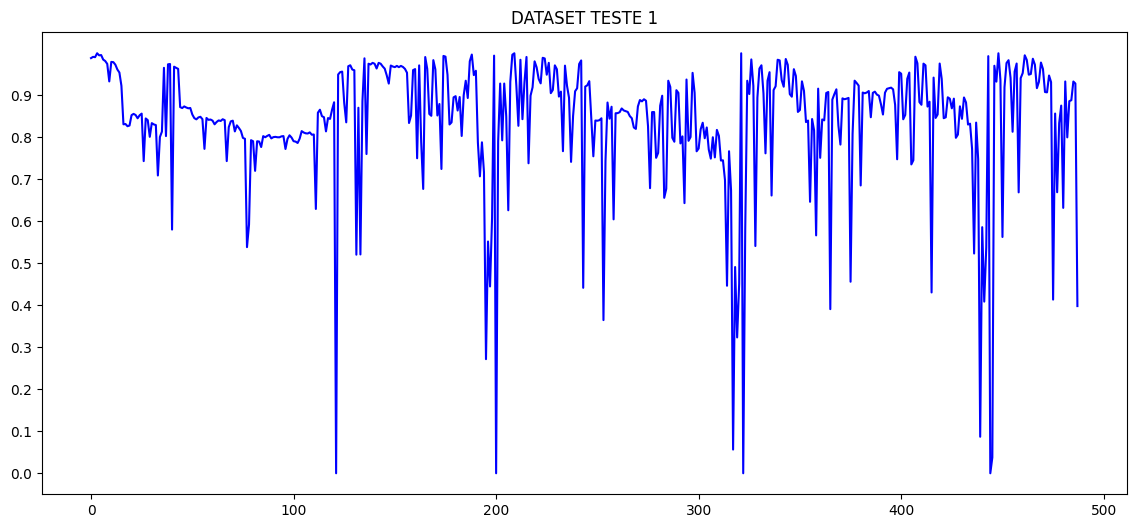

In [24]:
plt.figure(figsize=(14,6))
plt.plot(dataset_test_3, label="Original", color='blue')
plt.yticks(np.arange(0,1,step=0.1))
plt.title("DATASET TESTE 1")
plt.show()

In [25]:
timesteps = config['datasets'][dataset_type_du]["timesteps"]
output_steps = config['datasets'][dataset_type_du]["output_horizon"]
X_3, y_3 = create_dataset(dataset_test_3, timesteps, output_steps)
X_3 = X_3.reshape(X_3.shape[0], X_3.shape[1], 1)

#model3 = create_model(config, dataset_type_du, X_3, y_3, validation_method, 3)

X shape (458, 1)
y shape (458, 30)



Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

 9/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1259 

16/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1295

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1310 - val_loss: 0.1015


Epoch 7: early stopping


Restoring model weights from the end of the best epoch: 3.


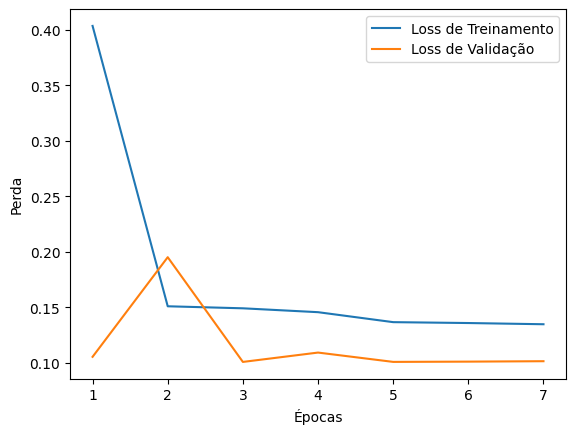

X shape (43, 1)
y shape (43, 30)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 21/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1452

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.1452 - val_loss: 0.1338


Epoch 21: early stopping


Restoring model weights from the end of the best epoch: 17.


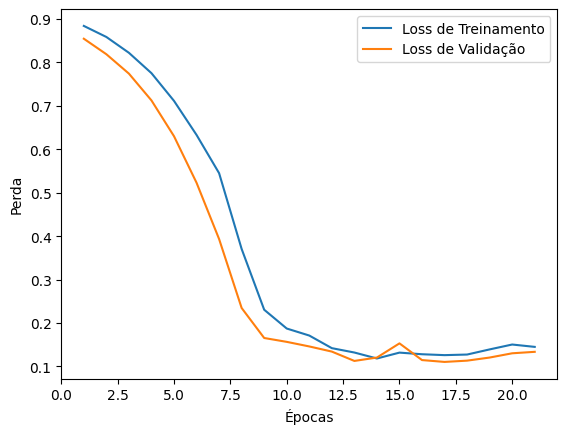

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step


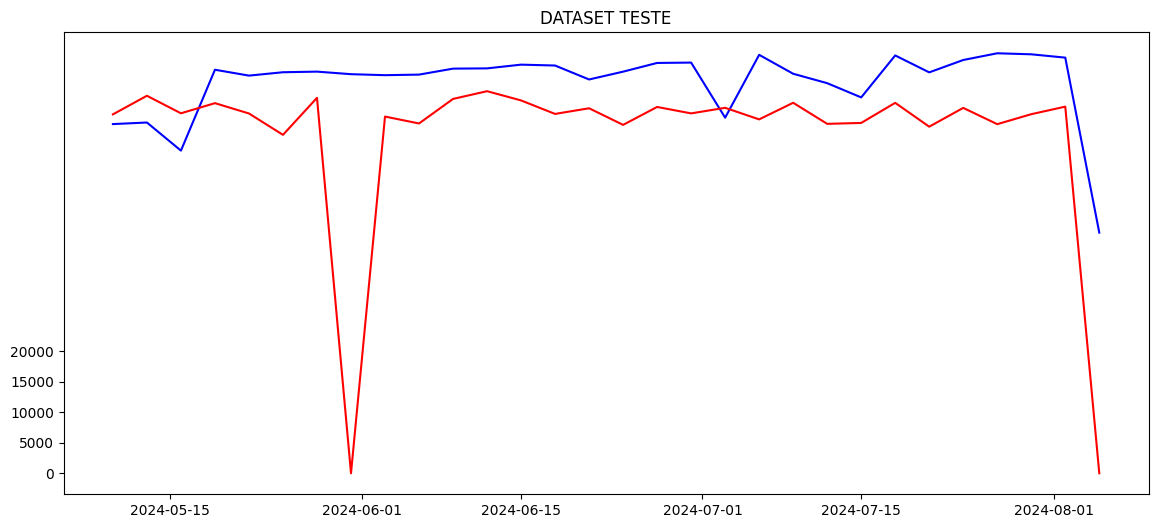

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.1.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

 8/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1289 

15/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1254

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1243 - val_loss: 0.1164


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 11.


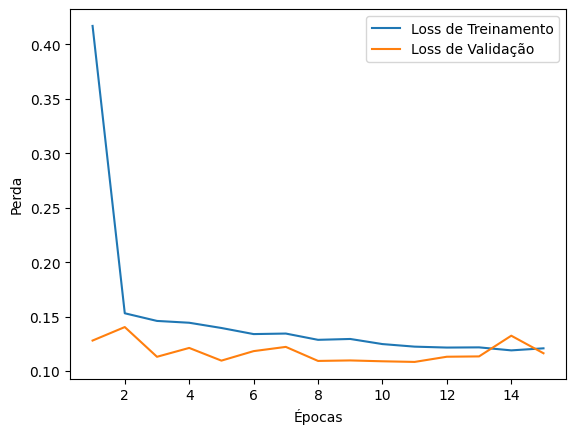

X shape (43, 1)
y shape (43, 30)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                        │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 26/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0697

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0697 - val_loss: 0.0502


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 22.


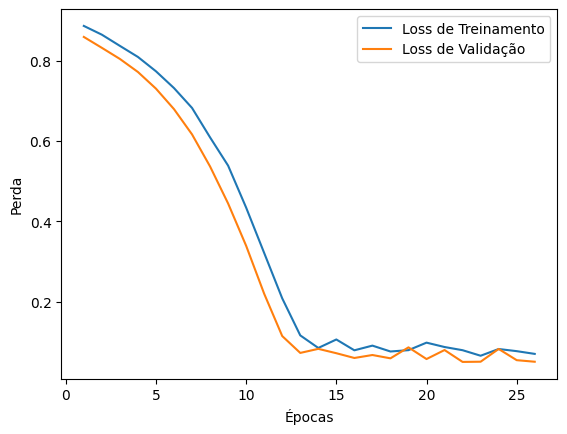

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 899ms/step


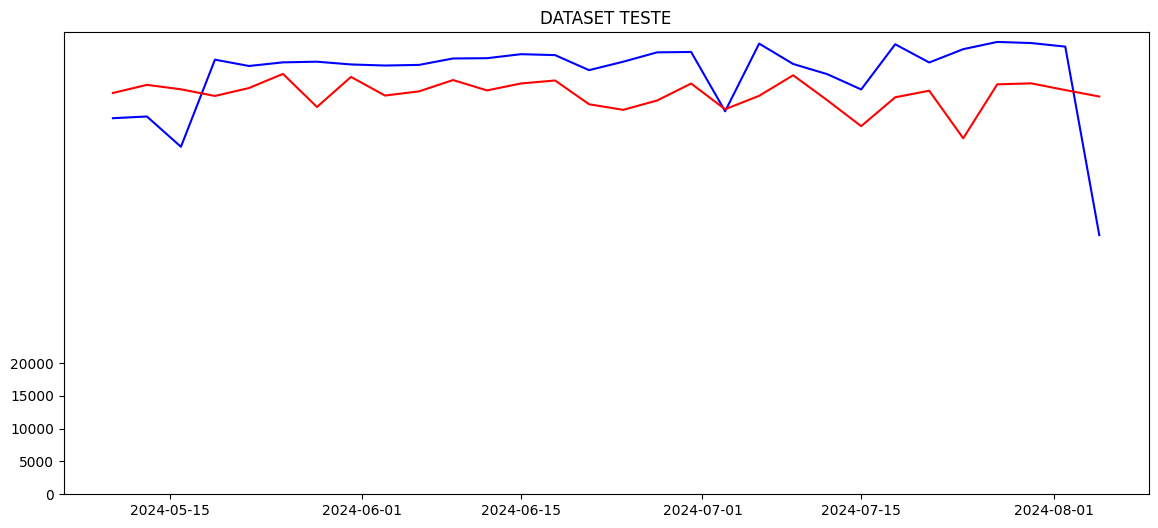

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.2.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                        │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1547

 9/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1428 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1407 - val_loss: 0.1190


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 1.


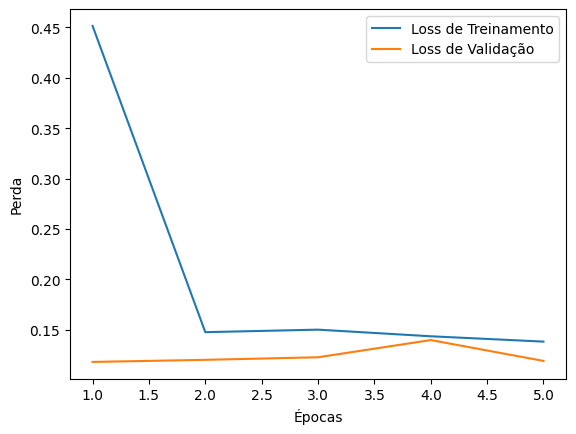

X shape (43, 1)
y shape (43, 30)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_11 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 17/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.1415

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.1415 - val_loss: 0.1343


Epoch 17: early stopping


Restoring model weights from the end of the best epoch: 13.


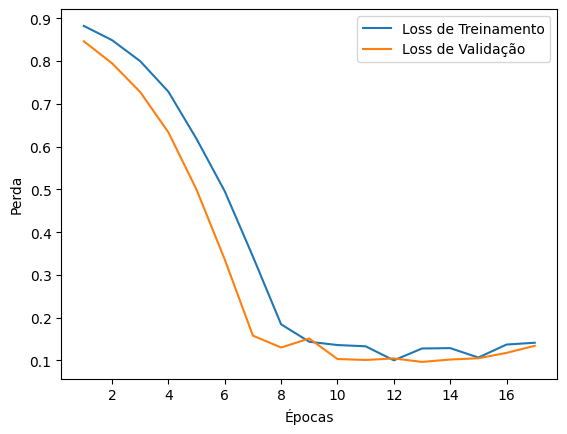

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step


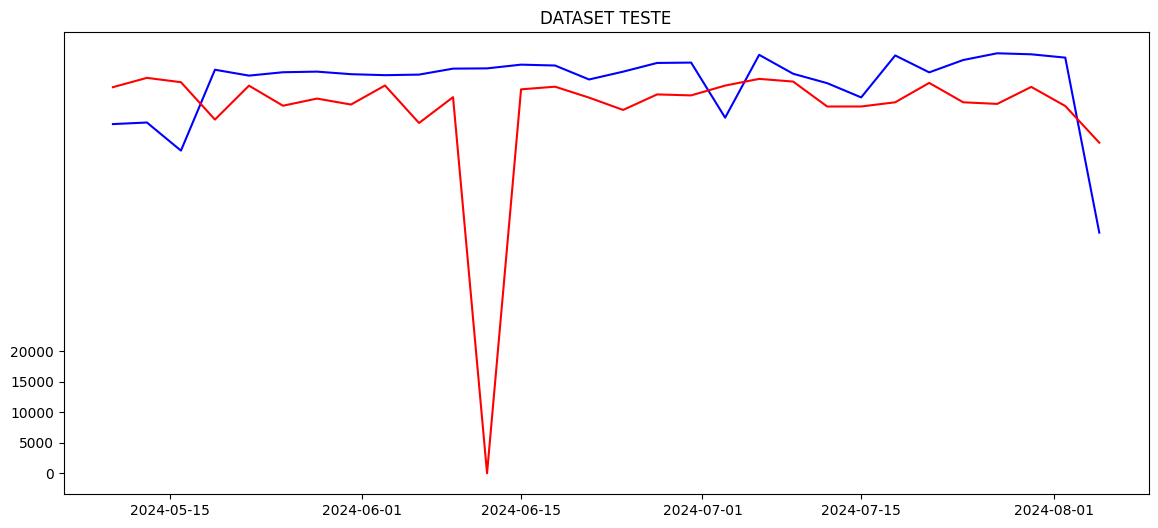

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.30000000000000004.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_13 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

 1/14 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1408

 8/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1346 

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1315 - val_loss: 0.1280


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 7.


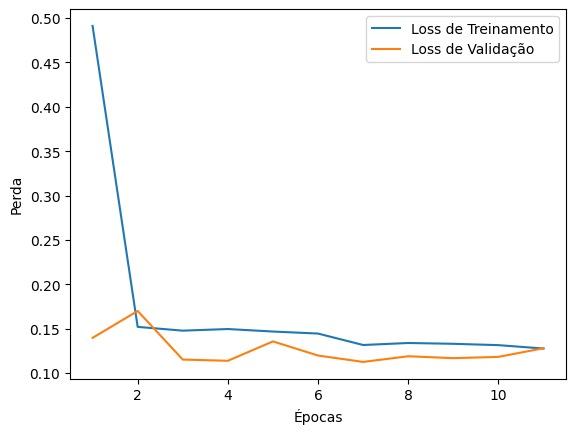

X shape (43, 1)
y shape (43, 30)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 20/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0953

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0953 - val_loss: 0.0761


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 16.


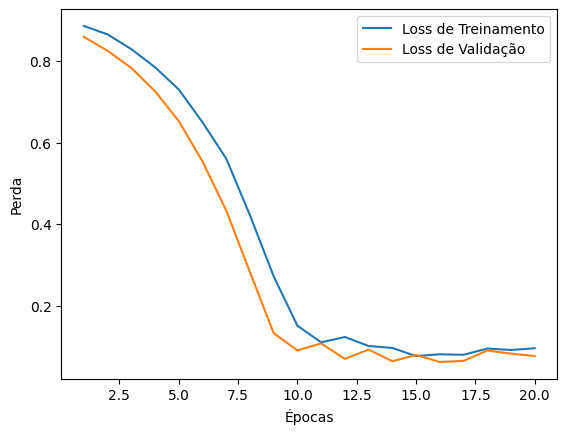

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step


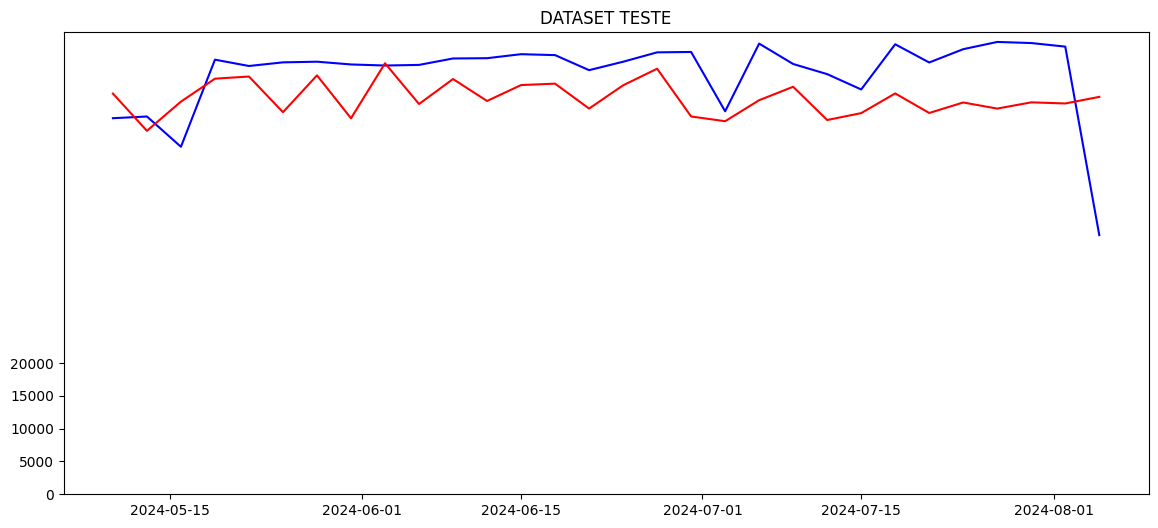

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.4.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1287

 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1308 

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1316 - val_loss: 0.1236


Epoch 12: early stopping


Restoring model weights from the end of the best epoch: 8.


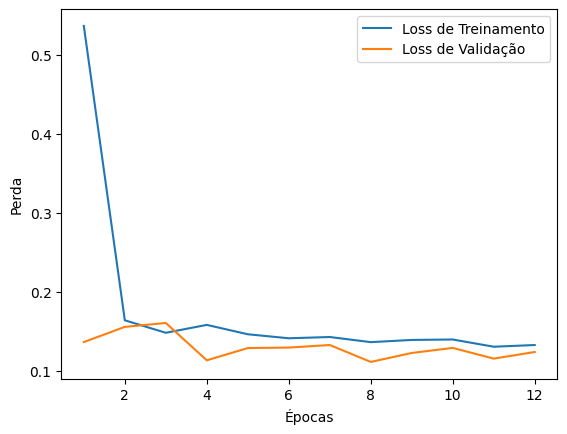

X shape (43, 1)
y shape (43, 30)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_19 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 15/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0810

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0810 - val_loss: 0.0712


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 11.


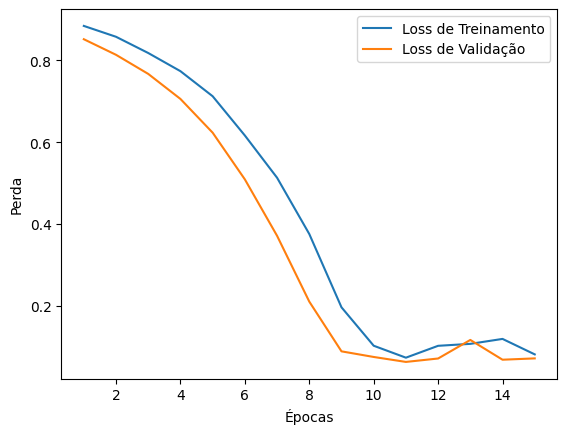

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step


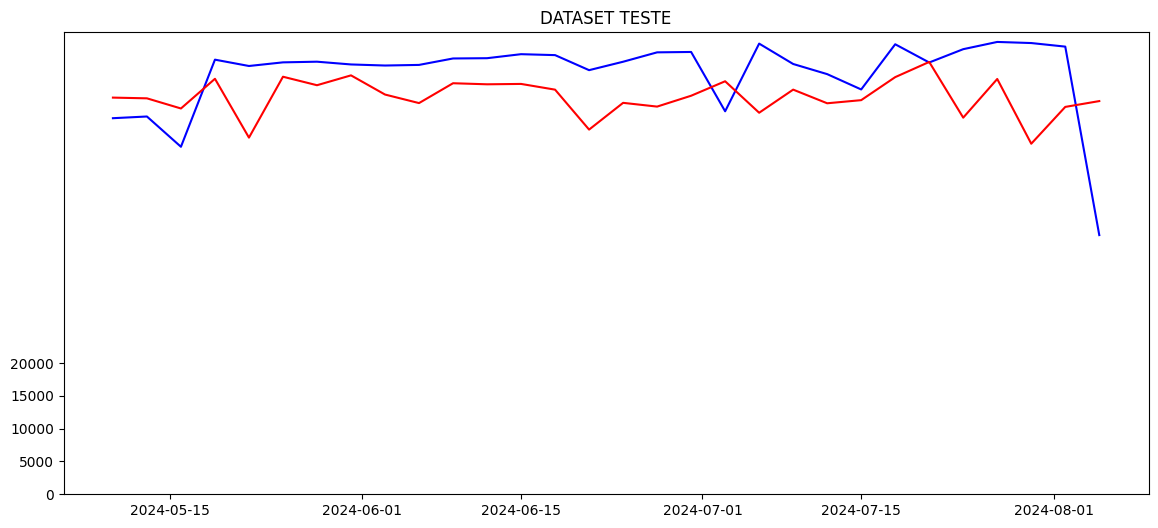

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.5.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_21 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.1505

 8/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1486 

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1490 - val_loss: 0.1922


Epoch 5: early stopping


Restoring model weights from the end of the best epoch: 1.


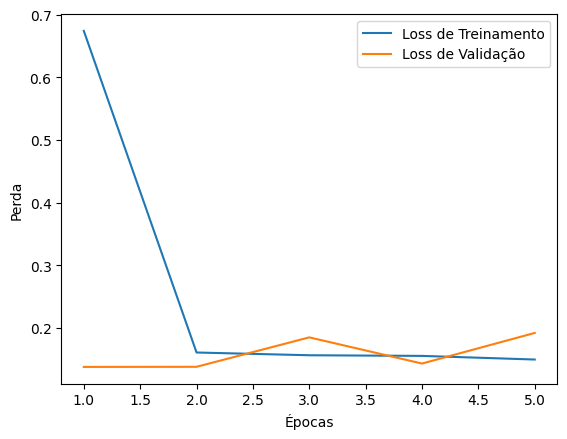

X shape (43, 1)
y shape (43, 30)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_23 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 15/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.1108

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.1108 - val_loss: 0.0806


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 11.


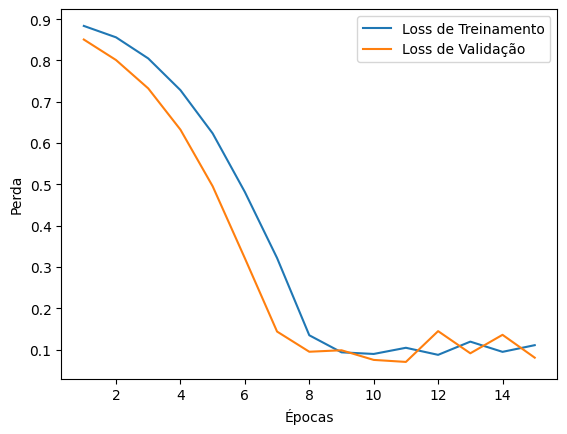

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step


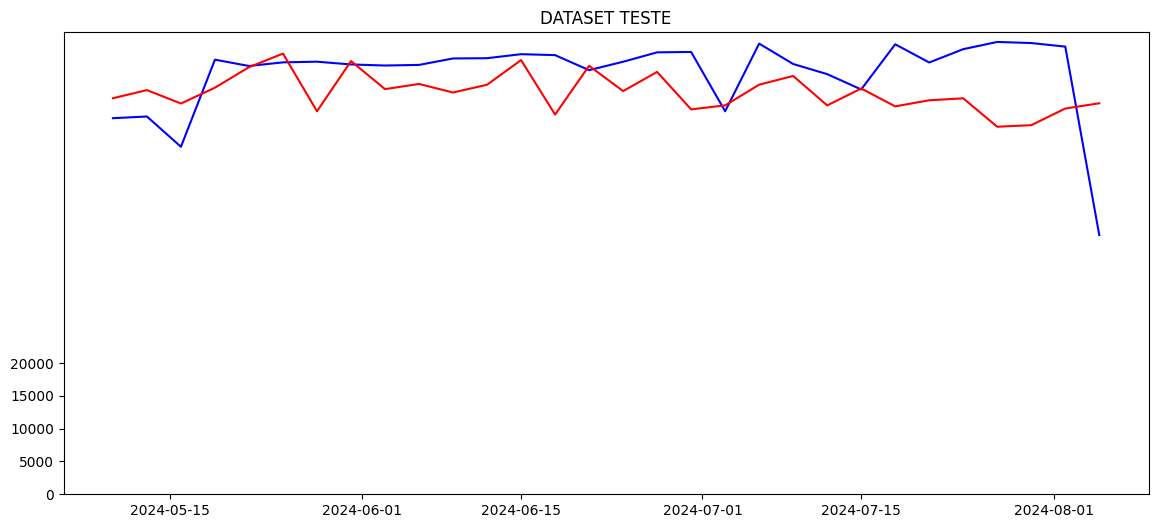

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.6.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_25 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

Epoch 8/100000


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.1404

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1421 - val_loss: 0.1166


Epoch 8: early stopping


Restoring model weights from the end of the best epoch: 4.


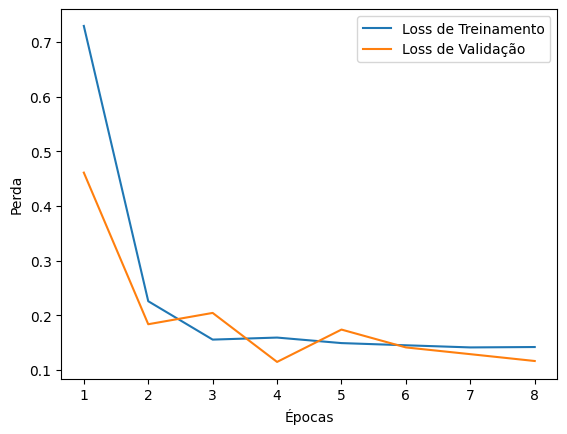

X shape (43, 1)
y shape (43, 30)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_27 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 14/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.1269

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1269 - val_loss: 0.1121


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 10.


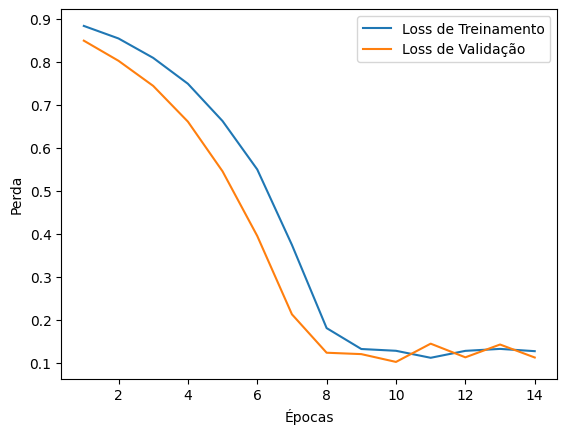

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


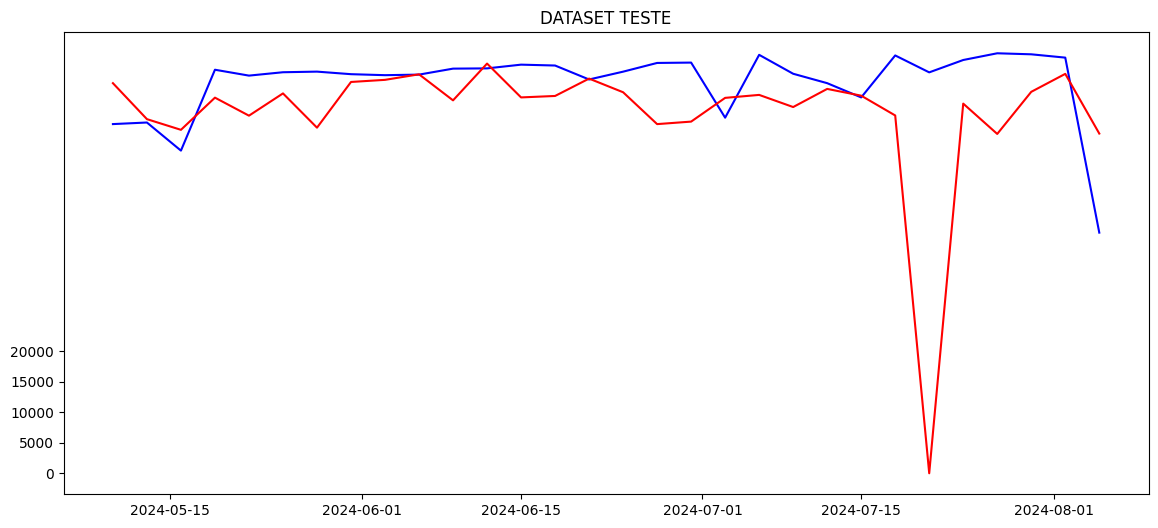

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.7.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_29 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

Epoch 10/100000


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1532

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.1482 - val_loss: 0.1251


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 6.


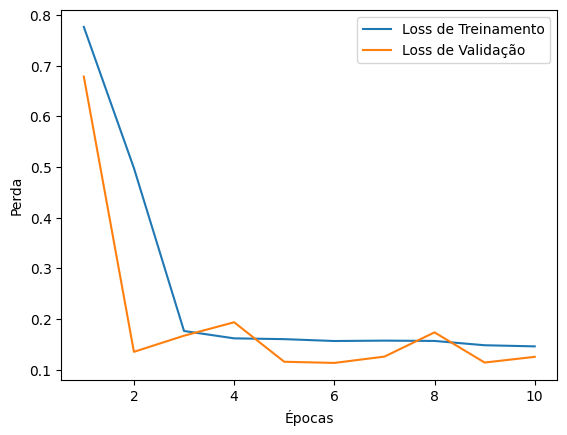

X shape (43, 1)
y shape (43, 30)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_31 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 15/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.1304

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.1304 - val_loss: 0.1128


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 11.


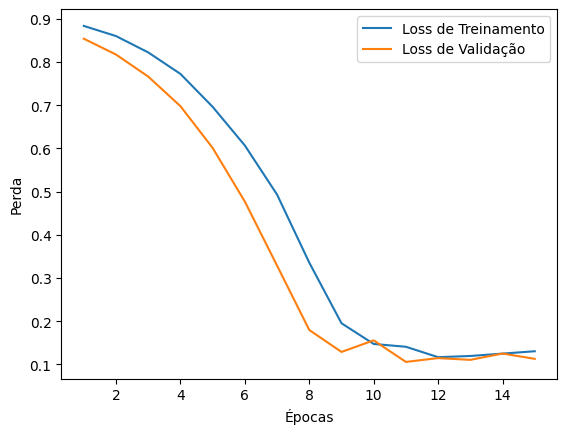

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step


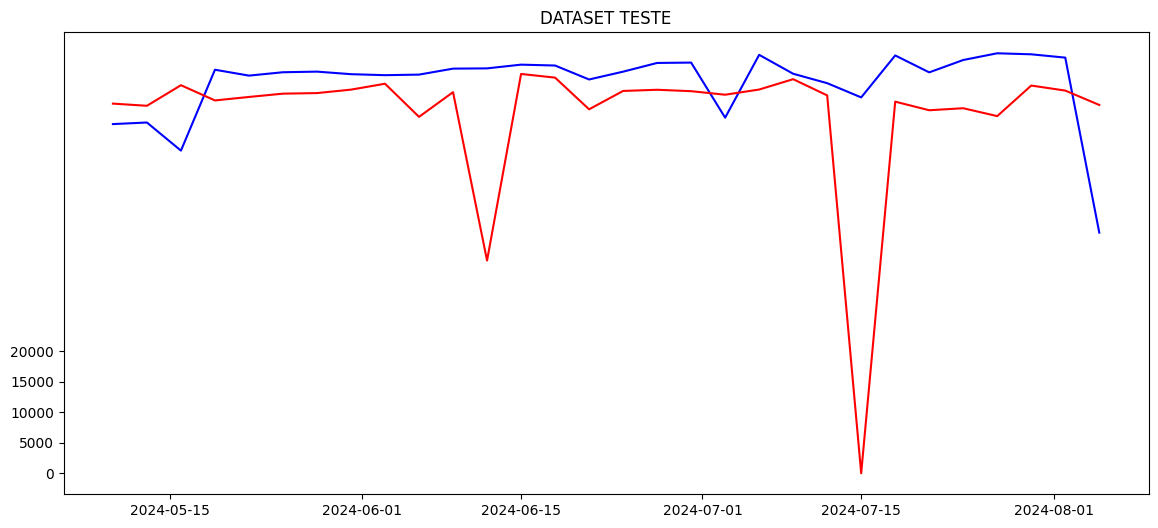

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.7999999999999999.txt

Training with train-test split


C:\Users\Renan Torres\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_32 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_33 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

...

Epoch 14/100000


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.1440

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.1471 - val_loss: 0.1194


Epoch 14: early stopping


Restoring model weights from the end of the best epoch: 10.


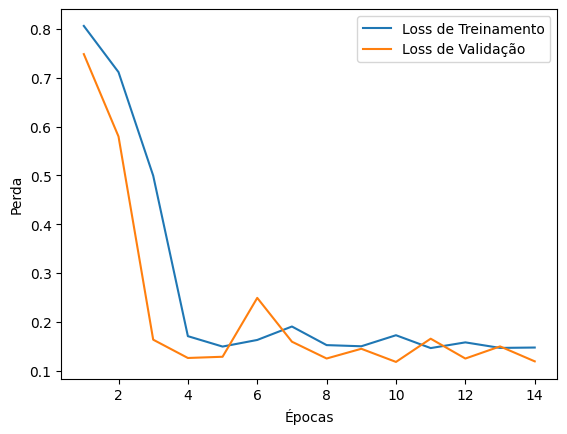

X shape (43, 1)
y shape (43, 30)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_34 (LSTM)                       │ (None, 1, 150)              │          91,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_34 (Dropout)                 │ (None, 1, 150)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_35 (LSTM)                       │ (None, 150)                 │         180,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 30)                  │           4,530 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276,330 (1.05 MB)

 Trainable params: 276,330 (1.05 MB)

...

Epoch 13/100000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1166

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.1166 - val_loss: 0.1154


Epoch 13: early stopping


Restoring model weights from the end of the best epoch: 9.


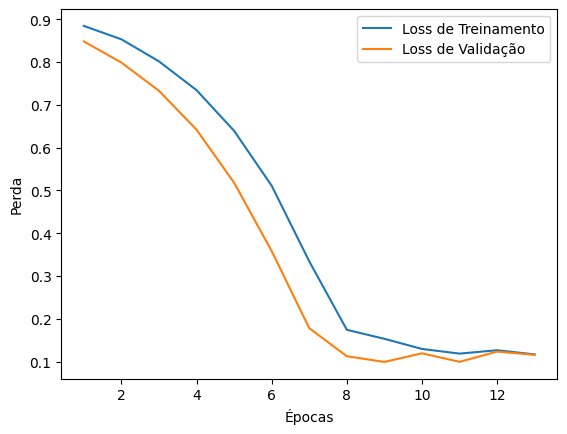

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step


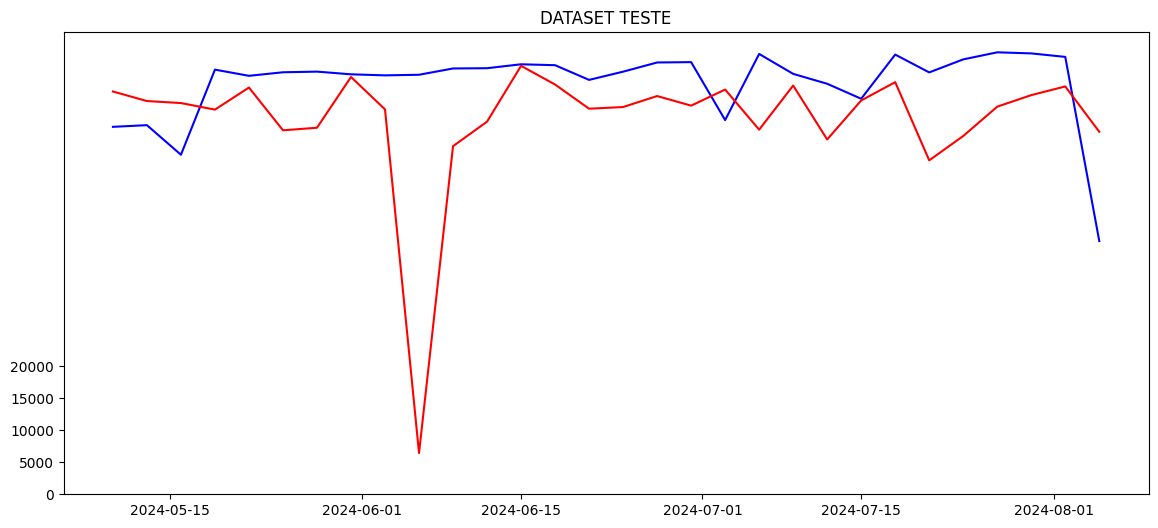

Output salvo em: Resultados_PSO/pso_concat/3_days/avaliacao_testes/teste_3__0.8\avaliacao_with_method_split_0.8999999999999999.txt


In [26]:
# Treinamento com k-fold cross-validation para k entre 2 e 9
# for k in range(2, 10):
#     validation_method = 'k-fold'
#     print(f"\nTraining with k-fold cross-validation, k={k}")
#     model3 = train_model(X_3, y_3, validation_method, k, tt_rate=0)
#     transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3, 'teste_3', validation_method, str(k))
    
# Treinamento com train-test split
tt_rate = 0
for k in range(1,10):
    tt_rate += 0.10
    print("\nTraining with train-test split")
    validation_method = 'split'
    model3 = create_and_train_model(config, dataset_type_du, X_3, y_3, validation_method, None, tt_rate)
    transfer_learning_model(config, model3, diretorio_pesos_teste_3, diretorio_avaliacao_teste_3,'teste_3', validation_method, tt_rate, tt_rate_new)

In [27]:
# # Salvamento dos pesos após primeiro treinamento

# pesos_treinamento3 = model3.get_weights()
# pesos_LSTM1_t3 = model3.layers[0].get_weights()
# pesos_LSTM2_t3 = model3.layers[2].get_weights()
# pesos_LSTM3_t3 = model3.layers[4].get_weights()
# pesos_DENSE_t3 = model3.layers[6].get_weights()

# # Salvar pesos de cada camada LSTM em arquivos .npz
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'), *pesos_LSTM1_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'), *pesos_LSTM2_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'), *pesos_LSTM3_t3)
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_DENSE_t3_{validation_method}.npz'), *pesos_DENSE_t3)

# # Para salvar os pesos do modelo completo
# np.savez(os.path.join(diretorio_pesos_teste_3, f'pesos_modelo_t3_{validation_method}.npz'), *pesos_treinamento3)

In [28]:
# # Carregar pesos do arquivo .npz
# pesos_carregados_LSTM1_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz'))
# pesos_carregados_LSTM2_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz'))
# pesos_carregados_LSTM3_t3 = np.load(os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz'))

In [29]:
# X, y = create_dataset(scaled_datasets[4], timesteps, output_steps)
# X = X.reshape(X.shape[0], X.shape[1], 1)

# model3_ft = Sequential()

# for _ in range(int(config['datasets'][dataset_type_du]['layers'])):
#     model3_ft.add(LSTM(int(config['datasets'][dataset_type_du]['neurons']),
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #recurrent_initializer=GlorotUniform(),  # Inicializador para os pesos recorrentes
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os bias
#                     return_sequences=True if _ < int(config['datasets'][dataset_type_du]["layers"]) - 1 else False, input_shape=(X.shape[1], 1)))

#     model3_ft.add(Dropout(0.3))

# model3_ft.add(Dense(config['datasets'][dataset_type_du]['output_horizon'], 
#                     #kernel_initializer=GlorotUniform(),  # Inicializador para os pesos
#                     #bias_initializer=GlorotUniform(),  # Inicializador para os biases
#                     activation=config['datasets'][dataset_type_du]['activation']))

# model3_ft.summary()

In [30]:
# # Caminho dos pesos salvos
# caminho_LSTM1_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM1_t3_{validation_method}.npz')
# caminho_LSTM2_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM2_t3_{validation_method}.npz')
# caminho_LSTM3_t3 = os.path.join(diretorio_pesos_teste_3, f'pesos_LSTM3_t3_{validation_method}.npz')

# carregar_e_aplicar_pesos(model3_ft, caminho_LSTM1_t3, caminho_LSTM2_t3, caminho_LSTM3_t3)

In [31]:
# # Verifica se os pesos de cada camada do novo modelo são iguais ao pesos salvos anteriormente

# ### CAMADA LSTM 1
# sao_iguais1 = np.array_equal(pesos_LSTM1_t3[0], model3_ft.layers[0].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM1_t3[1], model3_ft.layers[0].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM1_t3[2], model3_ft.layers[0].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# ### CAMADA LSTM 2
# sao_iguais1 = np.array_equal(pesos_LSTM2_t3[0], model3_ft.layers[2].get_weights()[0])
# sao_iguais2 = np.array_equal(pesos_LSTM2_t3[1], model3_ft.layers[2].get_weights()[1])
# sao_iguais3 = np.array_equal(pesos_LSTM2_t3[2], model3_ft.layers[2].get_weights()[2])

# print(sao_iguais1)
# print(sao_iguais2)
# print(sao_iguais3)

# # ### CAMADA LSTM 3
# # sao_iguais1 = np.array_equal(pesos_LSTM3_t3[0], model3_ft.layers[4].get_weights()[0])
# # sao_iguais2 = np.array_equal(pesos_LSTM3_t3[1], model3_ft.layers[4].get_weights()[1])
# # sao_iguais3 = np.array_equal(pesos_LSTM3_t3[2], model3_ft.layers[4].get_weights()[2])

# # print(sao_iguais1)
# # print(sao_iguais2)
# # print(sao_iguais3)

In [32]:
# congelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.005

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [33]:
# descongelar_camadas(model3_ft)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# learning_rate = 0.0008

# # Configurar o otimizador
# optimizer = config['datasets'][dataset_type_du]['optimizer']
    
# if optimizer == 'adam':
#     opt = Adam(learning_rate=learning_rate)
# elif optimizer == 'rmsprop':
#     opt = RMSprop(learning_rate=learning_rate)
# else:
#     opt = SGD(learning_rate=learning_rate)

# # Configurar a função de perda
# loss_function = config['datasets'][dataset_type_du]["loss_function"]

# if loss_function == "wmae":
#     loss = wmae
# elif loss_function == "wmse":
#     loss = wmse

# model3_ft.compile(optimizer=opt, loss=loss)

# early_stopping = EarlyStopping(monitor='val_loss', verbose=2, patience=10, restore_best_weights=True) 

# history = model3_ft.fit(X_train, y_train, batch_size=config['datasets'][dataset_type_du]['batch_size'], epochs=100000, validation_data=(X_test, y_test), 
#                 callbacks=[early_stopping])
    
# # Ajuste do gráfico para começar em 1
# epochs_range = range(1, len(history.history['loss']) + 1)

# plt.plot(epochs_range, history.history['loss'], label='Loss de Treinamento')
# plt.plot(epochs_range, history.history['val_loss'], label='Loss de Validação')
# plt.xlabel('Épocas')
# plt.ylabel('Perda')
# plt.legend()
# plt.show()

In [34]:
# pred = model3_ft.predict(duas_unas_validation_scaled.iloc[0])
# y_pred_rescaled = scalers[4].inverse_transform(pred)
# y_pred_rescaled = y_pred_rescaled.reshape(-1)  # Converte para 1D, se necessário
# duas_unas_validation_rescaled = scalers[4].inverse_transform(duas_unas_validation_scaled[1:])

# plt.figure(figsize=(14,6))
# plt.plot(duas_unas_validation_scaled[1:].index, duas_unas_validation_rescaled, label="Original", color='blue')
# plt.plot(duas_unas_validation_scaled[1:].index, y_pred_rescaled, label="Predict", color='red')
# plt.yticks(np.arange(0,80000,step=10000))
# plt.title("DATASET TESTE 3")

# # Nome do arquivo incluindo a variável 'validation_method'
# file_name = f'prediction_plot_with_method_{validation_method}.png'

# # Caminho completo para salvar o arquivo
# save_path = os.path.join(diretorio_avaliacao_teste_3, file_name)

# # Salvar o plot
# plt.savefig(save_path)
# plt.show()

In [35]:
# avaliacao_multistep(duas_unas_validation_rescaled, y_pred_rescaled)

# # Nome do arquivo incluindo a variável 'validation_method'
# output_file = f'avaliacao_with_method_{validation_method}.txt'

# save_function_output(avaliacao_multistep, 
#                      duas_unas_validation_rescaled, 
#                      y_pred_rescaled, 
#                      output_file = output_file, 
#                      output_dir=diretorio_avaliacao_teste_3)